In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
two_levels_up = os.path.dirname(os.path.dirname(os.getcwd()))
parent_directory = two_levels_up#os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.dirname(os.getcwd()))

from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
import pyarrow.dataset as ds
from filter_df import prepare_and_compute_metrics

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [2]:
labelsparams = lambda p: labels[p]
label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}
CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
label_rmet_lat = [r"$\frac{RB(\pi_E)_{Roman+Rubin}}{RB(\pi_E)_{Roman}}$", r"$\frac{SB(\pi_E)_{Roman+Rubin}}{SB(\pi_E)_{Roman}}$", 
                 r"$\frac{NU(\pi_E)_{Roman+Rubin}}{NU(\pi_E)_{Roman}}$"]
param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(|\pi_{EE}|)$',r'$\log_{10}(|\pi_{EN}|)$']

dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}

In [3]:

model = 'FSPL'
system_type = "FFP"

if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]
    
from read_results_ import read_results
true, fit_roman, fit_rr, met_1_roman, met_1_rr, met_2_roman, met_2_rr, met_3_roman, met_3_rr, met1_ratio, met2_ratio, met3_ratio =read_results(system_type, model)


Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [8]:
# true

This graph qualitatively shows that the parallax is best measured for longer-lasting events.

In [9]:
# true.columns

In [10]:
# true

In [11]:
# len(true)

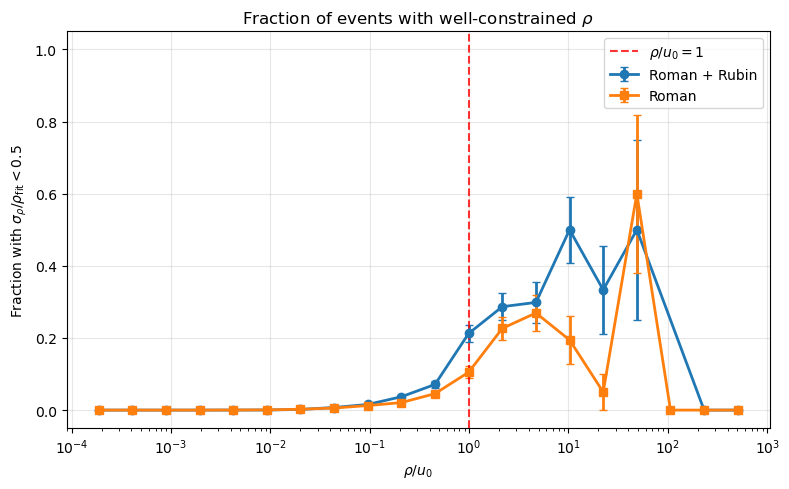

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def compute_fraction_good_rho_measurement(
    true,
    met_3,
    threshold=0.5,
    bins=None,
    n_bins=20,
    use_abs_u0=True,
):
    """
    Calcula la fracción de eventos con met_3["rho"] < threshold
    en bines de rho/u0.
    """

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    metric_rho = np.asarray(met_3["rho"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask = (
        np.isfinite(rho_over_u0)
        & np.isfinite(metric_rho)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    x = rho_over_u0[mask]
    y = metric_rho[mask]

    good = y < threshold

    if bins is None:
        bins = np.logspace(
            np.log10(np.nanmin(x)),
            np.log10(np.nanmax(x)),
            n_bins + 1
        )

    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    fractions = np.full(len(bins) - 1, np.nan)
    errors = np.full(len(bins) - 1, np.nan)
    counts = np.zeros(len(bins) - 1, dtype=int)
    good_counts = np.zeros(len(bins) - 1, dtype=int)

    for i in range(len(bins) - 1):

        in_bin = (x >= bins[i]) & (x < bins[i + 1])

        counts[i] = np.sum(in_bin)

        if counts[i] > 0:

            good_counts[i] = np.sum(good[in_bin])

            fractions[i] = good_counts[i] / counts[i]

            errors[i] = np.sqrt(
                fractions[i] * (1.0 - fractions[i]) / counts[i]
            )

    df_bins = pd.DataFrame(
        {
            "bin_left": bins[:-1],
            "bin_right": bins[1:],
            "bin_center": bin_centers,
            "N_total": counts,
            "N_good": good_counts,
            "fraction": fractions,
            "binomial_error": errors,
        }
    )

    return df_bins, bins


def plot_fraction_good_rho_measurement_comparison(
    true,
    met_3_rr,
    met_3_roman,
    threshold=0.5,
    n_bins=20,
    use_abs_u0=True,
):
    """
    Grafica juntas las fracciones de eventos con sigma_rho/rho_fit < threshold
    para Roman+Rubin y Roman, usando los mismos bines de rho/u0.
    """

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask_bins = (
        np.isfinite(rho_over_u0)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    x_bins = rho_over_u0[mask_bins]

    bins = np.logspace(
        np.log10(np.nanmin(x_bins)),
        np.log10(np.nanmax(x_bins)),
        n_bins + 1
    )

    df_rr, _ = compute_fraction_good_rho_measurement(
        true=true,
        met_3=met_3_rr,
        threshold=threshold,
        bins=bins,
        n_bins=n_bins,
        use_abs_u0=use_abs_u0,
    )

    df_roman, _ = compute_fraction_good_rho_measurement(
        true=true,
        met_3=met_3_roman,
        threshold=threshold,
        bins=bins,
        n_bins=n_bins,
        use_abs_u0=use_abs_u0,
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    valid_rr = df_rr["N_total"] > 0
    valid_roman = df_roman["N_total"] > 0

    ax.errorbar(
        df_rr.loc[valid_rr, "bin_center"],
        df_rr.loc[valid_rr, "fraction"],
        yerr=df_rr.loc[valid_rr, "binomial_error"],
        fmt="o-",
        capsize=3,
        lw=2,
        label="Roman + Rubin"
    )

    ax.errorbar(
        df_roman.loc[valid_roman, "bin_center"],
        df_roman.loc[valid_roman, "fraction"],
        yerr=df_roman.loc[valid_roman, "binomial_error"],
        fmt="s-",
        capsize=3,
        lw=2,
        label="Roman"
    )

    ax.axvline(
        1.0,
        color="red",
        linestyle="--",
        alpha=0.8,
        label=r"$\rho/u_0 = 1$"
    )

    ax.set_xscale("log")
    ax.set_ylim(-0.05, 1.05)

    ax.set_xlabel(r"$\rho/u_0$")
    ax.set_ylabel(
        rf"Fraction with $\sigma_\rho/\rho_{{\rm fit}} < {threshold}$"
    )

    ax.set_title(
        r"Fraction of events with well-constrained $\rho$"
    )

    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return df_rr, df_roman

df_rho_fraction_rr, df_rho_fraction_roman = plot_fraction_good_rho_measurement_comparison(
    true=true,
    met_3_rr=met_3_rr,
    met_3_roman=met_3_roman,
    threshold=0.5,
    n_bins=20
)

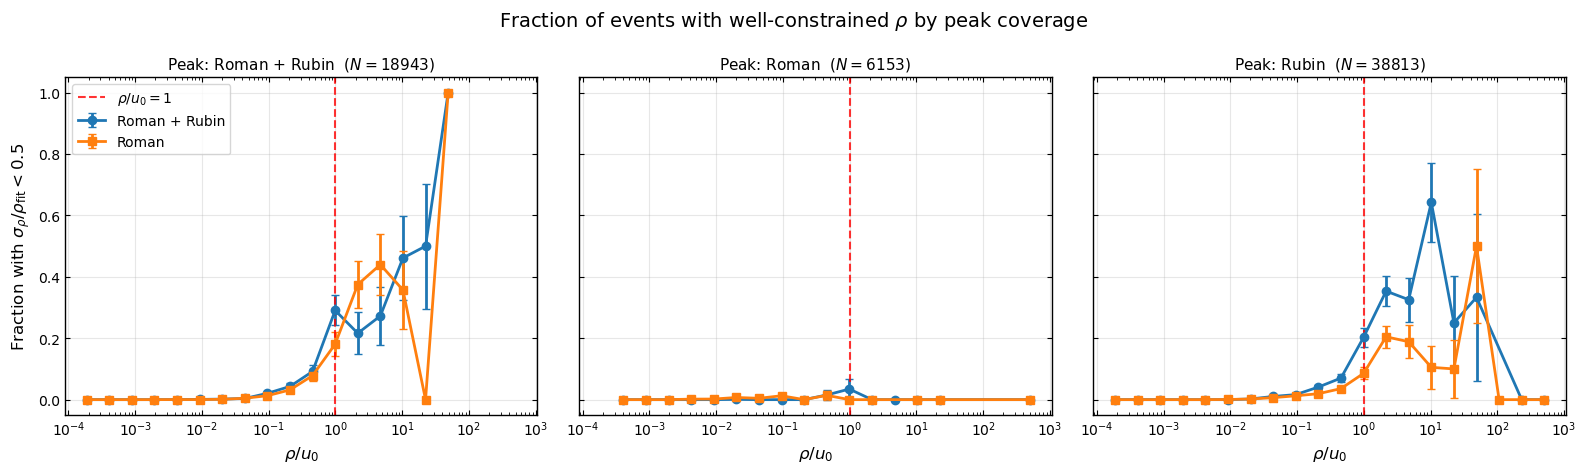

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def compute_fraction_good_rho_measurement(
    true,
    met_3,
    threshold=0.5,
    bins=None,
    n_bins=20,
    category_mask=None,
    use_abs_u0=True,
):
    """
    Calcula la fracción de eventos con met_3["rho"] < threshold
    en bines de rho/u0.

    Parameters
    ----------
    true : pandas.DataFrame
        Debe tener columnas "rho", "u0" y opcionalmente "peak_flag".

    met_3 : pandas.DataFrame
        Debe tener columna "rho", donde met_3["rho"] = sigma_rho / rho_fit.

    threshold : float
        Umbral para considerar rho bien medido.

    bins : array or None
        Bines en rho/u0. Si es None, se calculan automáticamente.

    n_bins : int
        Número de bines logarítmicos si bins is None.

    category_mask : array-like or None
        Máscara booleana para seleccionar una categoría de eventos.

    use_abs_u0 : bool
        Si True, usa rho/abs(u0).
    """

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    metric_rho = np.asarray(met_3["rho"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask = (
        np.isfinite(rho_over_u0)
        & np.isfinite(metric_rho)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    if category_mask is not None:
        category_mask = np.asarray(category_mask, dtype=bool)
        mask = mask & category_mask

    x = rho_over_u0[mask]
    y = metric_rho[mask]

    if len(x) == 0:
        if bins is None:
            bins = np.logspace(-3, 3, n_bins + 1)

        bin_centers = np.sqrt(bins[:-1] * bins[1:])

        return pd.DataFrame(
            {
                "bin_left": bins[:-1],
                "bin_right": bins[1:],
                "bin_center": bin_centers,
                "N_total": np.zeros(len(bins) - 1, dtype=int),
                "N_good": np.zeros(len(bins) - 1, dtype=int),
                "fraction": np.full(len(bins) - 1, np.nan),
                "binomial_error": np.full(len(bins) - 1, np.nan),
            }
        ), bins

    good = y < threshold

    if bins is None:
        bins = np.logspace(
            np.log10(np.nanmin(x)),
            np.log10(np.nanmax(x)),
            n_bins + 1
        )

    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    fractions = np.full(len(bins) - 1, np.nan)
    errors = np.full(len(bins) - 1, np.nan)
    counts = np.zeros(len(bins) - 1, dtype=int)
    good_counts = np.zeros(len(bins) - 1, dtype=int)

    for i in range(len(bins) - 1):

        in_bin = (x >= bins[i]) & (x < bins[i + 1])

        counts[i] = np.sum(in_bin)

        if counts[i] > 0:

            good_counts[i] = np.sum(good[in_bin])

            fractions[i] = good_counts[i] / counts[i]

            errors[i] = np.sqrt(
                fractions[i] * (1.0 - fractions[i]) / counts[i]
            )

    df_bins = pd.DataFrame(
        {
            "bin_left": bins[:-1],
            "bin_right": bins[1:],
            "bin_center": bin_centers,
            "N_total": counts,
            "N_good": good_counts,
            "fraction": fractions,
            "binomial_error": errors,
        }
    )

    return df_bins, bins


def plot_fraction_good_rho_measurement_by_peak_flag_comparison(
    true,
    met_3_rr,
    met_3_roman,
    threshold=0.5,
    n_bins=20,
    use_abs_u0=True,
):
    """
    Grafica la fracción de eventos con sigma_rho/rho_fit < threshold
    en función de rho/u0, separando por peak_flag.

    peak_flag:
        A : pico cubierto por Roman + Rubin
        B : pico cubierto por Roman
        C : pico cubierto por Rubin

    Nota:
    En los fits Roman-only, las categorías A y B se interpretan ambas como
    eventos con pico cubierto por Roman. Aun así, acá se grafican separadas
    usando la misma máscara de eventos que en Roman+Rubin, para comparar
    evento a evento dentro de cada subconjunto.
    """

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask_bins = (
        np.isfinite(rho_over_u0)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    x_bins = rho_over_u0[mask_bins]

    bins = np.logspace(
        np.log10(np.nanmin(x_bins)),
        np.log10(np.nanmax(x_bins)),
        n_bins + 1
    )

    peak_flags = np.asarray(true["peak_flag"]).astype(str)

    categories = ["A", "B", "C"]

    category_labels = {
        "A": "Peak: Roman + Rubin",
        "B": "Peak: Roman",
        "C": "Peak: Rubin",
    }

    results = {}

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 4.8),
        sharex=True,
        sharey=True
    )

    for ax, category in zip(axes, categories):

        category_mask = peak_flags == category

        df_rr, _ = compute_fraction_good_rho_measurement(
            true=true,
            met_3=met_3_rr,
            threshold=threshold,
            bins=bins,
            n_bins=n_bins,
            category_mask=category_mask,
            use_abs_u0=use_abs_u0,
        )

        df_roman, _ = compute_fraction_good_rho_measurement(
            true=true,
            met_3=met_3_roman,
            threshold=threshold,
            bins=bins,
            n_bins=n_bins,
            category_mask=category_mask,
            use_abs_u0=use_abs_u0,
        )

        results[category] = {
            "rr": df_rr,
            "roman": df_roman,
        }

        valid_rr = df_rr["N_total"] > 0
        valid_roman = df_roman["N_total"] > 0

        ax.errorbar(
            df_rr.loc[valid_rr, "bin_center"],
            df_rr.loc[valid_rr, "fraction"],
            yerr=df_rr.loc[valid_rr, "binomial_error"],
            fmt="o-",
            capsize=3,
            lw=2,
            label="Roman + Rubin"
        )

        ax.errorbar(
            df_roman.loc[valid_roman, "bin_center"],
            df_roman.loc[valid_roman, "fraction"],
            yerr=df_roman.loc[valid_roman, "binomial_error"],
            fmt="s-",
            capsize=3,
            lw=2,
            label="Roman"
        )

        ax.axvline(
            1.0,
            color="red",
            linestyle="--",
            alpha=0.8,
            label=r"$\rho/u_0 = 1$"
        )

        n_category = np.sum(category_mask)

        ax.set_xscale("log")
        ax.set_ylim(-0.05, 1.05)

        ax.set_title(
            rf"{category_labels[category]}  ($N={n_category}$)"
        )

        ax.set_xlabel(r"$\rho/u_0$")
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(
        rf"Fraction with $\sigma_\rho/\rho_{{\rm fit}} < {threshold}$"
    )

    axes[0].legend()

    fig.suptitle(
        r"Fraction of events with well-constrained $\rho$ by peak coverage",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    return results
results_rho_by_peak_flag = plot_fraction_good_rho_measurement_by_peak_flag_comparison(
    true=true,
    met_3_rr=met_3_rr,
    met_3_roman=met_3_roman,
    threshold=0.5,
    n_bins=20
)

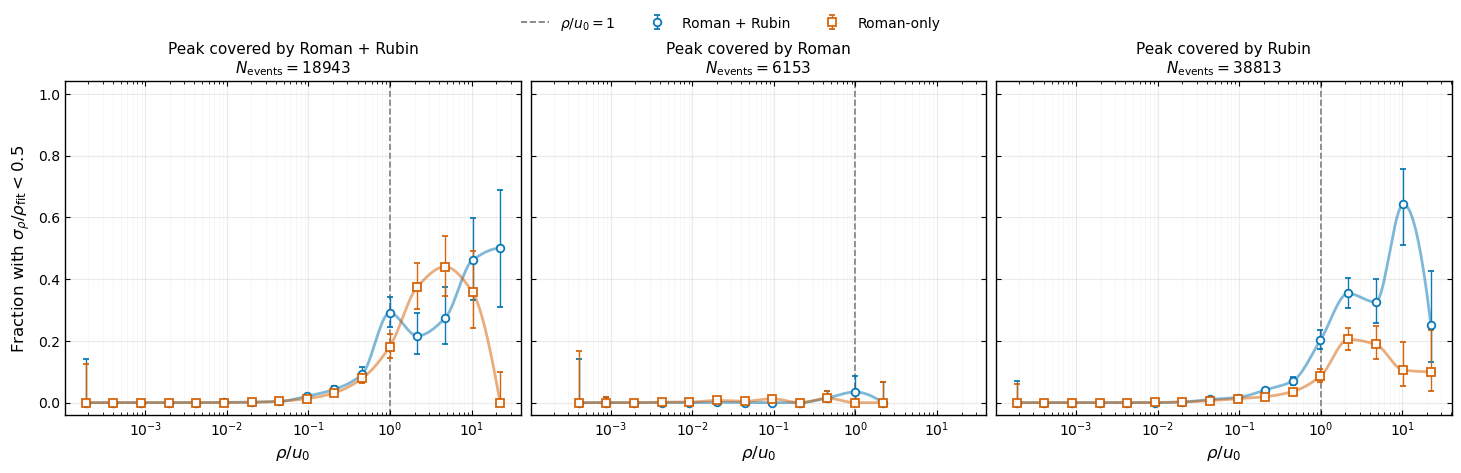

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# Binomial confidence interval
# ============================================================

def wilson_interval(k, n, z=1.0):
    """
    Wilson binomial confidence interval.

    z=1.0 gives an approximately 68% interval, comparable to 1-sigma.
    z=1.96 gives an approximately 95% interval.
    """

    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)

    p = np.full_like(k, np.nan, dtype=float)
    low = np.full_like(k, np.nan, dtype=float)
    high = np.full_like(k, np.nan, dtype=float)

    valid = n > 0

    p[valid] = k[valid] / n[valid]

    denom = 1.0 + z**2 / n[valid]

    center = (
        p[valid] + z**2 / (2.0 * n[valid])
    ) / denom

    half_width = (
        z
        * np.sqrt(
            p[valid] * (1.0 - p[valid]) / n[valid]
            + z**2 / (4.0 * n[valid]**2)
        )
        / denom
    )

    low[valid] = np.clip(center - half_width, 0.0, 1.0)
    high[valid] = np.clip(center + half_width, 0.0, 1.0)

    return p, low, high


# ============================================================
# Compute binned fraction
# ============================================================

def compute_fraction_good_rho_measurement(
    true,
    met_3,
    threshold=0.5,
    bins=None,
    n_bins=20,
    category_mask=None,
    use_abs_u0=True,
    z_wilson=1.0,
):
    """
    Computes the fraction of events with

        sigma_rho / rho_fit < threshold

    in logarithmic bins of rho/u0.
    """

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    metric_rho = np.asarray(met_3["rho"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask = (
        np.isfinite(rho_over_u0)
        & np.isfinite(metric_rho)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    if category_mask is not None:
        category_mask = np.asarray(category_mask, dtype=bool)
        mask = mask & category_mask

    x = rho_over_u0[mask]
    y = metric_rho[mask]

    if bins is None:
        if len(x) == 0:
            bins = np.logspace(-3, 3, n_bins + 1)
        else:
            bins = np.logspace(
                np.log10(np.nanmin(x)),
                np.log10(np.nanmax(x)),
                n_bins + 1,
            )

    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    counts = np.zeros(len(bins) - 1, dtype=int)
    good_counts = np.zeros(len(bins) - 1, dtype=int)

    for i in range(len(bins) - 1):

        in_bin = (x >= bins[i]) & (x < bins[i + 1])

        counts[i] = np.sum(in_bin)

        if counts[i] > 0:
            good_counts[i] = np.sum(y[in_bin] < threshold)

    fraction, frac_low, frac_high = wilson_interval(
        good_counts,
        counts,
        z=z_wilson,
    )

    err_low = np.maximum(fraction - frac_low, 0.0)
    err_high = np.maximum(frac_high - fraction, 0.0)
    
    df_bins = pd.DataFrame(
        {
            "bin_left": bins[:-1],
            "bin_right": bins[1:],
            "bin_center": bin_centers,
            "N_total": counts,
            "N_good": good_counts,
            "fraction": fraction,
            "frac_low": frac_low,
            "frac_high": frac_high,
            "err_low": err_low,
            "err_high": err_high,
        }
    )

    return df_bins, bins


# ============================================================
# Smooth guide curve
# ============================================================

def add_smooth_guide(
    ax,
    x,
    y,
    color,
    lw=2.0,
    alpha=0.5,
    n_points=300,
):
    """
    Adds a smooth guide curve in log10(x).

    Uses PCHIP if scipy is available. Otherwise falls back to linear
    interpolation. This is only a visual guide and should not be interpreted
    as a fit.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)

    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    logx = np.log10(x)

    # Avoid duplicated x-values
    logx_unique, unique_idx = np.unique(logx, return_index=True)
    y_unique = y[unique_idx]

    if len(logx_unique) < 3:
        return

    logx_smooth = np.linspace(
        np.nanmin(logx_unique),
        np.nanmax(logx_unique),
        n_points,
    )

    try:
        from scipy.interpolate import PchipInterpolator

        interpolator = PchipInterpolator(logx_unique, y_unique)
        y_smooth = interpolator(logx_smooth)

    except Exception:
        y_smooth = np.interp(logx_smooth, logx_unique, y_unique)

    x_smooth = 10**logx_smooth
    y_smooth = np.clip(y_smooth, 0.0, 1.0)

    ax.plot(
        x_smooth,
        y_smooth,
        color=color,
        lw=lw,
        alpha=alpha,
        zorder=2,
    )


# ============================================================
# Paper-style plot
# ============================================================

def plot_fraction_good_rho_measurement_by_peak_flag_comparison(
    true,
    met_3_rr,
    met_3_roman,
    threshold=0.5,
    n_bins=20,
    use_abs_u0=True,
    min_count_per_bin=5,
    z_wilson=1.0,
    smooth=True,
    savepath=None,
):
    """
    Plots the fraction of events with well-constrained rho:

        sigma_rho / rho_fit < threshold

    as a function of rho/u0, split by peak_flag.

    peak_flag convention used here:
        A : peak covered by Roman + Rubin
        B : peak covered by Roman
        C : peak covered by Rubin

    For Roman-only fits, categories A and B both correspond to cases where
    Roman covers the peak. They are still plotted separately to compare the
    same event subsets as in the Roman+Rubin case.
    """

    # -----------------------------
    # Common bins for all panels
    # -----------------------------

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask_bins = (
        np.isfinite(rho_over_u0)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    x_bins = rho_over_u0[mask_bins]

    bins = np.logspace(
        np.log10(np.nanmin(x_bins)),
        np.log10(np.nanmax(x_bins)),
        n_bins + 1,
    )

    peak_flags = np.asarray(true["peak_flag"]).astype(str)

    categories = ["A", "B", "C"]

    category_labels = {
        "A": "Peak covered by Roman + Rubin",
        "B": "Peak covered by Roman",
        "C": "Peak covered by Rubin",
    }

    colors = {
        "rr": "#0072B2",      # blue
        "roman": "#D55E00",   # vermillion
    }

    markers = {
        "rr": "o",
        "roman": "s",
    }

    labels = {
        "rr": "Roman + Rubin",
        "roman": "Roman-only",
    }

    results = {}

    # -----------------------------
    # Matplotlib style
    # -----------------------------

    plt.rcParams.update(
        {
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 11,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.linewidth": 1.0,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.top": True,
            "ytick.right": True,
            "savefig.dpi": 300,
        }
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14.5, 4.3),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for ax, category in zip(axes, categories):

        category_mask = peak_flags == category

        df_rr, _ = compute_fraction_good_rho_measurement(
            true=true,
            met_3=met_3_rr,
            threshold=threshold,
            bins=bins,
            n_bins=n_bins,
            category_mask=category_mask,
            use_abs_u0=use_abs_u0,
            z_wilson=z_wilson,
        )

        df_roman, _ = compute_fraction_good_rho_measurement(
            true=true,
            met_3=met_3_roman,
            threshold=threshold,
            bins=bins,
            n_bins=n_bins,
            category_mask=category_mask,
            use_abs_u0=use_abs_u0,
            z_wilson=z_wilson,
        )

        results[category] = {
            "rr": df_rr,
            "roman": df_roman,
        }

        for key, df in zip(
            ["rr", "roman"],
            [df_rr, df_roman],
        ):

            valid = (
                np.isfinite(df["fraction"])
                & (df["N_total"] >= min_count_per_bin)
            )

            x = df.loc[valid, "bin_center"].to_numpy()
            y = df.loc[valid, "fraction"].to_numpy()

            yerr = np.vstack(
                [
                    df.loc[valid, "err_low"].to_numpy(),
                    df.loc[valid, "err_high"].to_numpy(),
                ]
            )

            # Points + binomial uncertainty
            ax.errorbar(
                x,
                y,
                yerr=yerr,
                fmt=markers[key],
                ms=5.5,
                mfc="white",
                mec=colors[key],
                mew=1.3,
                color=colors[key],
                ecolor=colors[key],
                elinewidth=1.0,
                capsize=2.5,
                alpha=0.95,
                linestyle="none",
                label=labels[key],
                zorder=3,
            )

            # Smooth visual guide
            if smooth:
                add_smooth_guide(
                    ax=ax,
                    x=x,
                    y=y,
                    color=colors[key],
                    lw=2.0,
                    alpha=0.5,
                )

        # Reference line rho/u0 = 1
        ax.axvline(
            1.0,
            color="0.25",
            linestyle="--",
            lw=1.2,
            alpha=0.7,
            label=r"$\rho/u_0 = 1$",
            zorder=1,
        )

        n_category = int(np.sum(category_mask & mask_bins))

        ax.set_xscale("log")
        ax.set_ylim(-0.04, 1.04)

        ax.set_title(
            rf"{category_labels[category]}"
            "\n"
            rf"$N_{{\rm events}}={n_category}$"
        )

        ax.set_xlabel(r"$\rho/u_0$")

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

    axes[0].set_ylabel(
        rf"Fraction with $\sigma_\rho / \rho_{{\rm fit}} < {threshold}$"
    )

    # One common legend
    handles, legend_labels = axes[0].get_legend_handles_labels()

    # Remove duplicated labels
    unique = dict(zip(legend_labels, handles))

    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.08),
    )

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")

    plt.show()

    return results
results_rho_by_peak_flag = plot_fraction_good_rho_measurement_by_peak_flag_comparison(
    true=true,
    met_3_rr=met_3_rr,
    met_3_roman=met_3_roman,
    threshold=0.5,
    n_bins=20,
    min_count_per_bin=5,
    smooth=True,
    savepath="fraction_good_rho_by_peak_flag.png",
)

In [84]:
peak_flags = np.asarray(true["peak_flag"]).astype(str)

rho_true = np.asarray(true["rho"], dtype=float)
u0_true = np.abs(np.asarray(true["u0"], dtype=float))
rho_over_u0 = rho_true / u0_true

for cat in ["A", "B", "C"]:
    m = (
        (peak_flags == cat)
        & np.isfinite(rho_over_u0)
        & (rho_over_u0 > 0)
    )

    print("\nCategory", cat)
    print("N =", np.sum(m))
    print("fraction rho/u0 > 1 =", np.mean(rho_over_u0[m] > 1))
    print("fraction rho/u0 > 0.5 =", np.mean(rho_over_u0[m] > 0.5))
    print("median rho/u0 =", np.nanmedian(rho_over_u0[m]))
    print("max rho/u0 =", np.nanmax(rho_over_u0[m]))


Category A
N = 18943
fraction rho/u0 > 1 = 0.00638758380404371
fraction rho/u0 > 0.5 = 0.013197487198437418
median rho/u0 = 0.008027310216223818
max rho/u0 = 36.76884821226164

Category B
N = 6153
fraction rho/u0 > 1 = 0.005688282138794084
fraction rho/u0 > 0.5 = 0.013489354786283114
median rho/u0 = 0.0117445056924804
max rho/u0 = 748.0293589933073

Category C
N = 38813
fraction rho/u0 > 1 = 0.007420194264808183
fraction rho/u0 > 0.5 = 0.014763094839357947
median rho/u0 = 0.009033290703153347
max rho/u0 = 421.98531769104403


In [85]:
for key in ["rr", "roman"]:
    df = results_rho_by_peak_flag["B"][key]
    valid = df["N_total"] >= 5

    print("\nB", key)
    print(df.loc[valid, [
        "bin_left",
        "bin_right",
        "N_total",
        "N_good",
        "fraction"
    ]])


B rr
    bin_left  bin_right  N_total  N_good  fraction
1   0.000276   0.000602        6       0  0.000000
2   0.000602   0.001312       59       0  0.000000
3   0.001312   0.002861      391       0  0.000000
4   0.002861   0.006239     1222       0  0.000000
5   0.006239   0.013606     1582       0  0.000000
6   0.013606   0.029669     1311       1  0.000763
7   0.029669   0.064698      696       0  0.000000
8   0.064698   0.141083      330       0  0.000000
9   0.141083   0.307653      150       0  0.000000
10  0.307653   0.670883       66       1  0.015152
11  0.670883   1.462960       29       1  0.034483
12  1.462960   3.190202       14       0  0.000000

B roman
    bin_left  bin_right  N_total  N_good  fraction
1   0.000276   0.000602        5       0  0.000000
2   0.000602   0.001312       56       0  0.000000
3   0.001312   0.002861      393       0  0.000000
4   0.002861   0.006239     1197       2  0.001671
5   0.006239   0.013606     1555       3  0.001929
6   0.013606   0

In [86]:
peak_flags = np.asarray(true["peak_flag"]).astype(str)

rho_true = np.asarray(true["rho"], dtype=float)
u0_true = np.abs(np.asarray(true["u0"], dtype=float))
tE_true = np.asarray(true["tE"], dtype=float)

rho_over_u0 = rho_true / u0_true
t_star = rho_true * tE_true

metric_rho_rr = np.asarray(met_3_rr["rho"], dtype=float)
metric_rho_roman = np.asarray(met_3_roman["rho"], dtype=float)

mask_B_high = (
    (peak_flags == "B")
    & np.isfinite(rho_over_u0)
    & np.isfinite(t_star)
    & np.isfinite(metric_rho_rr)
    & np.isfinite(metric_rho_roman)
    & (rho_over_u0 > 1.0)
)

df_B_high = pd.DataFrame({
    "index": np.where(mask_B_high)[0],
    "rho": rho_true[mask_B_high],
    "u0": u0_true[mask_B_high],
    "rho_over_u0": rho_over_u0[mask_B_high],
    "tE": tE_true[mask_B_high],
    "t_star_days": t_star[mask_B_high],
    "t_star_hours": 24.0 * t_star[mask_B_high],
    "metric_rho_rr": metric_rho_rr[mask_B_high],
    "metric_rho_roman": metric_rho_roman[mask_B_high],
})

df_B_high = df_B_high.sort_values("rho_over_u0", ascending=False)

print(df_B_high)
print()
print("N B with rho/u0 > 1 =", len(df_B_high))
print("N good RR =", np.sum(df_B_high["metric_rho_rr"] < 0.5))
print("N good Roman =", np.sum(df_B_high["metric_rho_roman"] < 0.5))
print("median t_star hours =", np.nanmedian(df_B_high["t_star_hours"]))

    index       rho        u0  rho_over_u0         tE  t_star_days  \
9   17173  0.016170  0.000022   748.029359   2.200031     0.035575   
0    1170  0.007957  0.000022   368.094267   2.155327     0.017150   
16  38102  0.003882  0.000151    25.690845   6.644103     0.025795   
17  38677  0.002460  0.000172    14.309549   5.215926     0.012830   
13  28645  0.018235  0.001807    10.090779   3.019826     0.055066   
20  42457  0.010311  0.001149     8.977068  10.984185     0.113258   
14  28854  0.111412  0.036828     3.025219   0.197114     0.021961   
6   13664  0.029808  0.011890     2.506877   1.556937     0.046409   
8   16051  0.013561  0.005471     2.478941   6.646509     0.090135   
18  39990  0.007221  0.002960     2.439413   1.425382     0.010293   
12  25860  0.002149  0.000928     2.316107   4.913480     0.010558   
11  23775  0.014374  0.006699     2.145642  11.882800     0.170802   
23  45543  0.005785  0.002787     2.075479   5.667313     0.032786   
27  59734  0.007551 

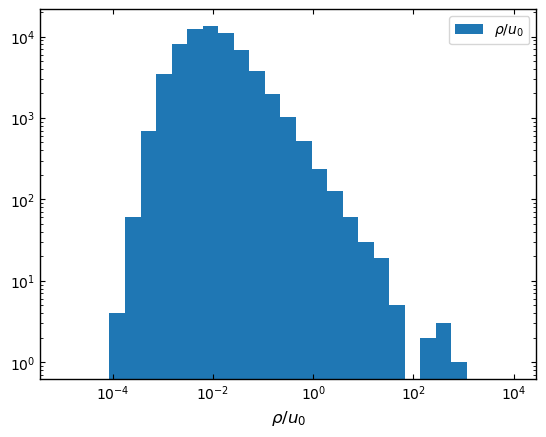

In [100]:
plt.hist(true["rho"]/abs(true["u0"]),bins=np.logspace(-5,4,30),label=r"$\rho/u_0$")
plt.xlabel(r"$\rho/u_0$")
plt.xscale("log")
plt.yscale("log")
plt.legend()

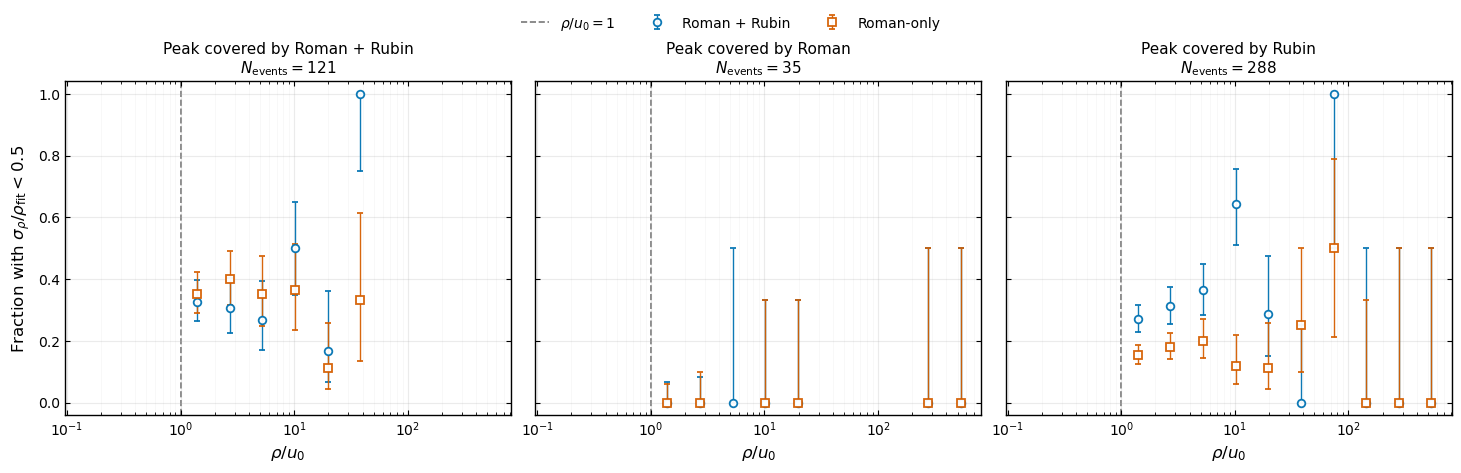

In [101]:
rho_true = np.asarray(true["rho"], dtype=float)
u0_true = np.abs(np.asarray(true["u0"], dtype=float))
rho_over_u0 = rho_true / u0_true

finite_source_geometry_mask = rho_over_u0 > 1.0

results_rho_by_peak_flag_fs_geometry = plot_fraction_good_rho_measurement_by_peak_flag_comparison(
    true=true[finite_source_geometry_mask],
    met_3_rr=met_3_rr[finite_source_geometry_mask],
    met_3_roman=met_3_roman[finite_source_geometry_mask],
    threshold=0.5,
    n_bins=10,
    min_count_per_bin=1,
    smooth=False,
    savepath="fraction_good_rho_by_peak_flag_fs_geometry.png",
)

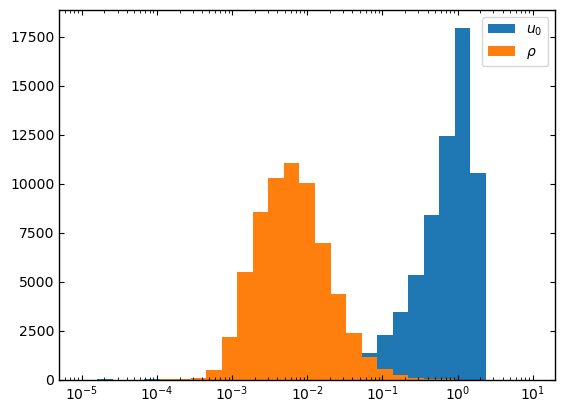

In [94]:
plt.hist(abs(true["u0"]),bins=np.logspace(-5,1,30),label=r"$u_0$")
plt.hist(true["rho"],bins=np.logspace(-5,1,30),label=r"$\rho$")
plt.xscale("log")
plt.legend()

Text(0, 0.5, '$M_L \\quad [M_{\\odot}]$')

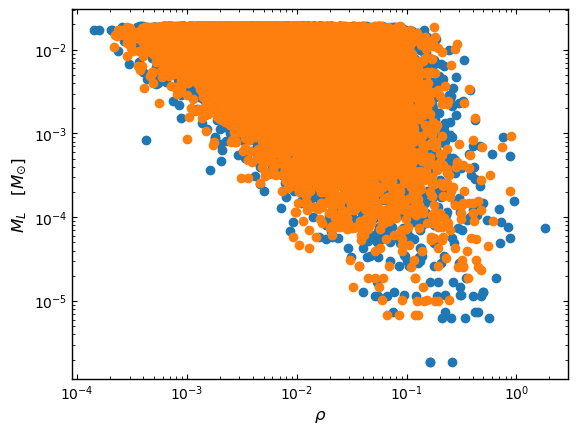

In [78]:
plt.scatter(true["rho"][true["u0"]<true["rho"]],abs(true["mass"][true["u0"]<true["rho"]]))
plt.scatter(true["rho"][true["u0"]>true["rho"]],abs(true["mass"][true["u0"]>true["rho"]]))
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$M_L \quad [M_{\odot}]$")

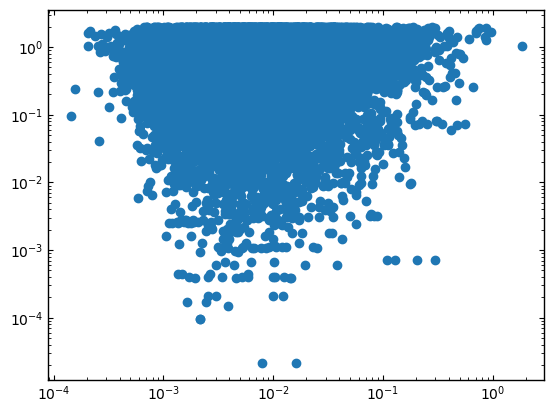

In [62]:
plt.scatter(true["rho"][true["u0"]<true["rho"]],abs(true["u0"][true["u0"]<true["rho"]]))
plt.yscale("log")
plt.xscale("log")

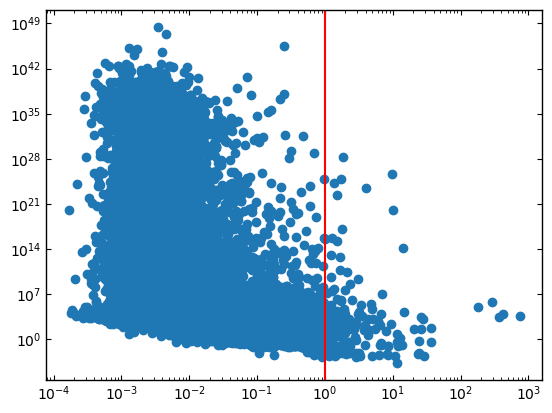

In [63]:
plt.scatter(true["rho"]/true["u0"],met_3_rr["rho"])
plt.axvline(1,color="red")
plt.yscale("log")
plt.xscale("log")

Text(0, 0.5, '$\\rho = \\frac{\\theta_s}{\\theta_E}$')

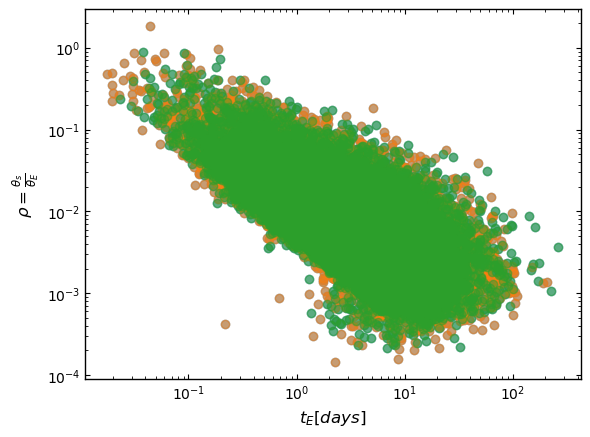

In [74]:
plt.scatter(true["tE"],true["rho"],alpha=0.5)
mask_rho = true["rho"]>true["u0"]
plt.scatter(true["tE"][mask_rho],true["rho"][mask_rho],alpha=0.5)
mask_rho = true["rho"]<true["u0"]
plt.scatter(true["tE"][mask_rho],true["rho"][mask_rho],alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$t_E [days]$")
plt.ylabel(r"$\rho = \frac{\theta_s}{\theta_E}$")

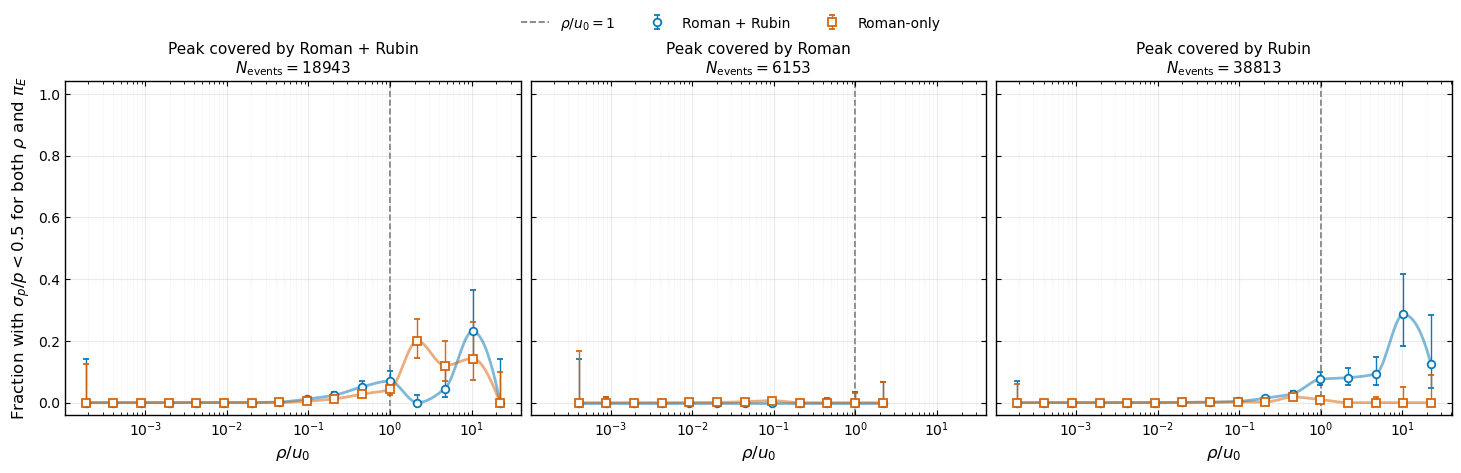

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# Binomial confidence interval
# ============================================================

def wilson_interval(k, n, z=1.0):
    """
    Wilson binomial confidence interval.

    z=1.0 gives an approximately 68% interval, comparable to 1-sigma.
    z=1.96 gives an approximately 95% interval.
    """

    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)

    p = np.full_like(k, np.nan, dtype=float)
    low = np.full_like(k, np.nan, dtype=float)
    high = np.full_like(k, np.nan, dtype=float)

    valid = n > 0

    p[valid] = k[valid] / n[valid]

    denom = 1.0 + z**2 / n[valid]

    center = (
        p[valid] + z**2 / (2.0 * n[valid])
    ) / denom

    half_width = (
        z
        * np.sqrt(
            p[valid] * (1.0 - p[valid]) / n[valid]
            + z**2 / (4.0 * n[valid]**2)
        )
        / denom
    )

    low[valid] = np.clip(center - half_width, 0.0, 1.0)
    high[valid] = np.clip(center + half_width, 0.0, 1.0)

    return p, low, high


# ============================================================
# Utility: piE metric
# ============================================================

def get_piE_metric(met_3, pie_key="piE", pie_component_keys=("piEN", "piEE")):
    """
    Returns a metric for the relative uncertainty of piE.

    Preferred case:
        met_3["piE"] = sigma_piE / piE

    Fallback case:
        If met_3 does not contain "piE", but contains piEN and piEE,
        the code uses the conservative component criterion:

            max(sigma_piEN/piEN, sigma_piEE/piEE)

        Therefore, asking metric_piE < threshold is equivalent to requiring
        both components to be measured with sigma_p/p < threshold.

    This fallback is useful if your met_3 table only stores metrics for
    piEN and piEE separately.
    """

    if pie_key in met_3:
        return np.asarray(met_3[pie_key], dtype=float)

    kN, kE = pie_component_keys

    if (kN in met_3) and (kE in met_3):
        metric_piEN = np.asarray(met_3[kN], dtype=float)
        metric_piEE = np.asarray(met_3[kE], dtype=float)

        metric_piE = np.maximum(metric_piEN, metric_piEE)

        return metric_piE

    raise KeyError(
        "Could not find piE metric. Expected either met_3['piE'] "
        "or both met_3['piEN'] and met_3['piEE']."
    )


# ============================================================
# Compute binned fraction
# ============================================================

def compute_fraction_good_rho_and_piE_measurement(
    true,
    met_3,
    threshold=0.5,
    bins=None,
    n_bins=20,
    category_mask=None,
    use_abs_u0=True,
    z_wilson=1.0,
    pie_key="piE",
    pie_component_keys=("piEN", "piEE"),
):
    """
    Computes the fraction of events with both

        sigma_rho / rho < threshold

    and

        sigma_piE / piE < threshold

    in logarithmic bins of rho/u0.

    If met_3["piE"] exists, that is used directly.
    Otherwise, the code requires both piEN and piEE to satisfy sigma_p/p < threshold.
    """

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    metric_rho = np.asarray(met_3["rho"], dtype=float)
    metric_piE = get_piE_metric(
        met_3=met_3,
        pie_key=pie_key,
        pie_component_keys=pie_component_keys,
    )

    rho_over_u0 = rho_true / u0_true

    mask = (
        np.isfinite(rho_over_u0)
        & np.isfinite(metric_rho)
        & np.isfinite(metric_piE)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    if category_mask is not None:
        category_mask = np.asarray(category_mask, dtype=bool)
        mask = mask & category_mask

    x = rho_over_u0[mask]
    metric_rho = metric_rho[mask]
    metric_piE = metric_piE[mask]

    if bins is None:
        if len(x) == 0:
            bins = np.logspace(-3, 3, n_bins + 1)
        else:
            bins = np.logspace(
                np.log10(np.nanmin(x)),
                np.log10(np.nanmax(x)),
                n_bins + 1,
            )

    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    counts = np.zeros(len(bins) - 1, dtype=int)
    good_counts = np.zeros(len(bins) - 1, dtype=int)

    good_event = (
        (metric_rho < threshold)
        & (metric_piE < threshold)
    )

    for i in range(len(bins) - 1):

        in_bin = (x >= bins[i]) & (x < bins[i + 1])

        counts[i] = np.sum(in_bin)

        if counts[i] > 0:
            good_counts[i] = np.sum(good_event[in_bin])

    fraction, frac_low, frac_high = wilson_interval(
        good_counts,
        counts,
        z=z_wilson,
    )

    err_low = np.maximum(fraction - frac_low, 0.0)
    err_high = np.maximum(frac_high - fraction, 0.0)

    df_bins = pd.DataFrame(
        {
            "bin_left": bins[:-1],
            "bin_right": bins[1:],
            "bin_center": bin_centers,
            "N_total": counts,
            "N_good_rho_and_piE": good_counts,
            "fraction": fraction,
            "frac_low": frac_low,
            "frac_high": frac_high,
            "err_low": err_low,
            "err_high": err_high,
        }
    )

    return df_bins, bins


# ============================================================
# Smooth guide curve
# ============================================================

def add_smooth_guide(
    ax,
    x,
    y,
    color,
    lw=2.0,
    alpha=0.5,
    n_points=300,
):
    """
    Adds a smooth guide curve in log10(x).

    Uses PCHIP if scipy is available. Otherwise falls back to linear
    interpolation. This is only a visual guide and should not be interpreted
    as a fit.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)

    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    logx = np.log10(x)

    logx_unique, unique_idx = np.unique(logx, return_index=True)
    y_unique = y[unique_idx]

    if len(logx_unique) < 3:
        return

    logx_smooth = np.linspace(
        np.nanmin(logx_unique),
        np.nanmax(logx_unique),
        n_points,
    )

    try:
        from scipy.interpolate import PchipInterpolator

        interpolator = PchipInterpolator(logx_unique, y_unique)
        y_smooth = interpolator(logx_smooth)

    except Exception:
        y_smooth = np.interp(logx_smooth, logx_unique, y_unique)

    x_smooth = 10**logx_smooth
    y_smooth = np.clip(y_smooth, 0.0, 1.0)

    ax.plot(
        x_smooth,
        y_smooth,
        color=color,
        lw=lw,
        alpha=alpha,
        zorder=2,
    )


# ============================================================
# Paper-style plot
# ============================================================

def plot_fraction_good_rho_and_piE_measurement_by_peak_flag_comparison(
    true,
    met_3_rr,
    met_3_roman,
    threshold=0.5,
    n_bins=20,
    use_abs_u0=True,
    min_count_per_bin=5,
    z_wilson=1.0,
    smooth=True,
    savepath=None,
    pie_key="piE",
    pie_component_keys=("piEN", "piEE"),
):
    """
    Plots the fraction of events with both rho and piE well constrained:

        sigma_rho / rho < threshold

    and

        sigma_piE / piE < threshold

    as a function of rho/u0, split by peak_flag.

    If met_3["piE"] exists, piE is used directly.
    Otherwise, the fallback is:

        max(met_3["piEN"], met_3["piEE"]) < threshold

    which requires both piEN and piEE to satisfy sigma_p/p < threshold.
    """

    # -----------------------------
    # Common bins for all panels
    # -----------------------------

    rho_true = np.asarray(true["rho"], dtype=float)

    if use_abs_u0:
        u0_true = np.abs(np.asarray(true["u0"], dtype=float))
    else:
        u0_true = np.asarray(true["u0"], dtype=float)

    rho_over_u0 = rho_true / u0_true

    mask_bins = (
        np.isfinite(rho_over_u0)
        & (rho_over_u0 > 0)
        & (u0_true > 0)
        & (rho_true > 0)
    )

    x_bins = rho_over_u0[mask_bins]

    bins = np.logspace(
        np.log10(np.nanmin(x_bins)),
        np.log10(np.nanmax(x_bins)),
        n_bins + 1,
    )

    peak_flags = np.asarray(true["peak_flag"]).astype(str)

    categories = ["A", "B", "C"]

    category_labels = {
        "A": "Peak covered by Roman + Rubin",
        "B": "Peak covered by Roman",
        "C": "Peak covered by Rubin",
    }

    colors = {
        "rr": "#0072B2",
        "roman": "#D55E00",
    }

    markers = {
        "rr": "o",
        "roman": "s",
    }

    labels = {
        "rr": "Roman + Rubin",
        "roman": "Roman-only",
    }

    results = {}

    # -----------------------------
    # Matplotlib style
    # -----------------------------

    plt.rcParams.update(
        {
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 11,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "axes.linewidth": 1.0,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.top": True,
            "ytick.right": True,
            "savefig.dpi": 300,
        }
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14.5, 4.3),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for ax, category in zip(axes, categories):

        category_mask = peak_flags == category

        df_rr, _ = compute_fraction_good_rho_and_piE_measurement(
            true=true,
            met_3=met_3_rr,
            threshold=threshold,
            bins=bins,
            n_bins=n_bins,
            category_mask=category_mask,
            use_abs_u0=use_abs_u0,
            z_wilson=z_wilson,
            pie_key=pie_key,
            pie_component_keys=pie_component_keys,
        )

        df_roman, _ = compute_fraction_good_rho_and_piE_measurement(
            true=true,
            met_3=met_3_roman,
            threshold=threshold,
            bins=bins,
            n_bins=n_bins,
            category_mask=category_mask,
            use_abs_u0=use_abs_u0,
            z_wilson=z_wilson,
            pie_key=pie_key,
            pie_component_keys=pie_component_keys,
        )

        results[category] = {
            "rr": df_rr,
            "roman": df_roman,
        }

        for key, df in zip(
            ["rr", "roman"],
            [df_rr, df_roman],
        ):

            valid = (
                np.isfinite(df["fraction"])
                & (df["N_total"] >= min_count_per_bin)
            )

            x = df.loc[valid, "bin_center"].to_numpy()
            y = df.loc[valid, "fraction"].to_numpy()

            yerr = np.vstack(
                [
                    df.loc[valid, "err_low"].to_numpy(),
                    df.loc[valid, "err_high"].to_numpy(),
                ]
            )

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                fmt=markers[key],
                ms=5.5,
                mfc="white",
                mec=colors[key],
                mew=1.3,
                color=colors[key],
                ecolor=colors[key],
                elinewidth=1.0,
                capsize=2.5,
                alpha=0.95,
                linestyle="none",
                label=labels[key],
                zorder=3,
            )

            if smooth:
                add_smooth_guide(
                    ax=ax,
                    x=x,
                    y=y,
                    color=colors[key],
                    lw=2.0,
                    alpha=0.5,
                )

        ax.axvline(
            1.0,
            color="0.25",
            linestyle="--",
            lw=1.2,
            alpha=0.7,
            label=r"$\rho/u_0 = 1$",
            zorder=1,
        )

        n_category = int(np.sum(category_mask & mask_bins))

        ax.set_xscale("log")
        ax.set_ylim(-0.04, 1.04)

        ax.set_title(
            rf"{category_labels[category]}"
            "\n"
            rf"$N_{{\rm events}}={n_category}$"
        )

        ax.set_xlabel(r"$\rho/u_0$")

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

    axes[0].set_ylabel(
        rf"Fraction with $\sigma_p/p < {threshold}$ for both $\rho$ and $\pi_E$"
    )

    handles, legend_labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(legend_labels, handles))

    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.08),
    )

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")

    plt.show()

    return results


# ============================================================
# Run
# ============================================================

results_rho_and_piE_by_peak_flag = (
    plot_fraction_good_rho_and_piE_measurement_by_peak_flag_comparison(
        true=true,
        met_3_rr=met_3_rr,
        met_3_roman=met_3_roman,
        threshold=0.5,
        n_bins=20,
        min_count_per_bin=5,
        smooth=True,
        savepath="fraction_good_rho_and_piE_by_peak_flag.png",
    )
)

In [8]:
seed = 100
np.random.seed(seed)
ROW_G = np.random.randint(0, 10000)
ROW_T = np.random.randint(0, 10000)

In [9]:
true["mass"].iloc[0]
Source = int(true["Source"].iloc[0])
print(Source)
Set = int(true['Set'].iloc[0])
print(Set)

from ulens_params import event_param
path_TRILEGAL = f"/home/anibal/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_{Set}.csv" 
path_GENULENS = f"/home/anibal/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/Genulens_chunk_{Set}.csv" 
data_TRILEGAL = pd.read_csv(path_TRILEGAL).iloc[ROW_T]
data_GENULENS= pd.read_csv(path_GENULENS).iloc[ROW_G]
event_param(Source, data_TRILEGAL, data_GENULENS, system_type)

100
1


{'t0': 2461653.454228777,
 'u0': 1.3791045292796147,
 'tE': 0.7413277203433386,
 'piEN': 0.22494070064711683,
 'piEE': 0.2348539607454705,
 'radius': 0.4122428774794102,
 'mass_star': 0,
 'mass_planet': 5.567410406914237,
 'thetaE': 0.014075110937425032,
 'thetas': 0.00024033120286860105,
 'rho': 0.01707490647406353}

In [10]:
5.567410406914237*u.M_jup.to("M_sun")

0.005314617872581144

In [11]:
system_type

'FFP'

In [12]:
true.iloc[0]

Source                              100
Set                                   1
t0                       2461653.454229
u0                             1.379105
tE                             0.741328
rho                            0.017075
piEN                           0.224941
piEE                           0.234854
Category                           None
mass                           0.005315
sel_crit                           None
piE                            0.325199
crit_FFP_Rubin                     None
W149                              51606
g                                   2.0
r                                   1.0
i                                   1.0
W149_peak                           176
g_peak                              0.0
r_peak                              0.0
i_peak                              0.0
W149_npeak                           44
g_npeak                             0.0
r_npeak                             0.0
i_npeak                             0.0


In [13]:

from astropy import constants as C
import astropy.units as u
import numpy as np

k = 4 * C.G / C.c**2

mass = np.asarray(true["mass"], dtype=float) * u.M_sun
piE  = np.asarray(true["piE"], dtype=float)

thetaE_rad = (k * mass * piE / u.AU).decompose()
thetaE_mas = thetaE_rad.to(u.mas, equivalencies=u.dimensionless_angles())

true["thetaE_mas"] = thetaE_mas.value

In [16]:
print(len(true[true["rho"]>true["u0"]]))
print(len(true[true["rho"]<true["u0"]]))


32437
31472


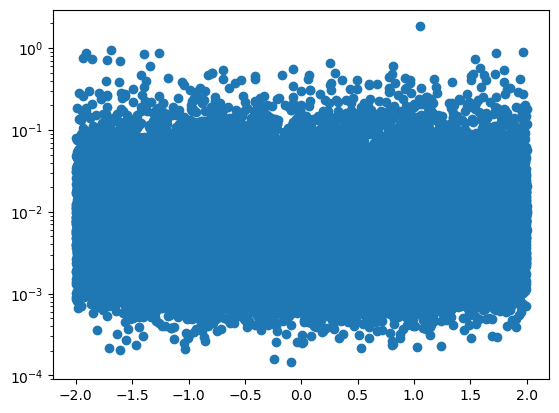

In [86]:
plt.scatter(true["u0"],true["rho"])
plt.yscale("log")

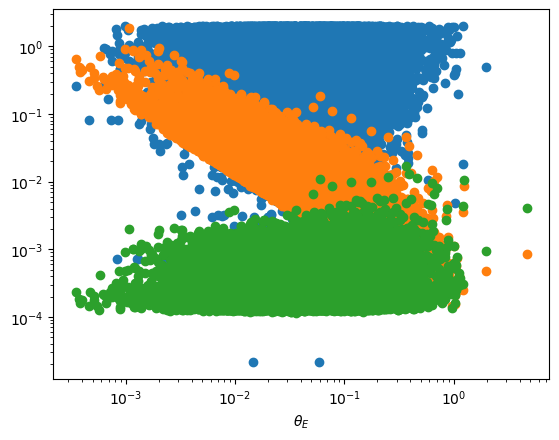

In [84]:
plt.scatter(true["thetaE_mas"],true["u0"])
plt.scatter(true["thetaE_mas"],true["rho"])
plt.scatter(true["thetaE_mas"],true["thetaE_mas"]*true["rho"])
plt.xlabel(r"$\theta_E$")
plt.xscale("log")
plt.yscale("log")

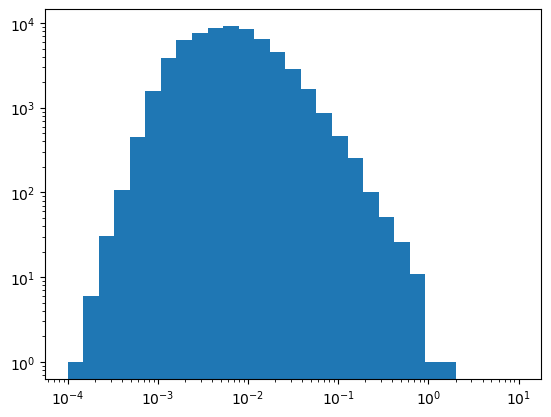

In [12]:
plt.hist(true["rho"], bins=np.logspace(-4,1,30))
plt.xscale("log")
plt.yscale("log")

In [4]:
true_filtered = true

$\pi_E = \frac{AU}{D_\perp}(\frac{\Delta t_0}{t_E}, \Delta u_0)$

63909 63909 63909


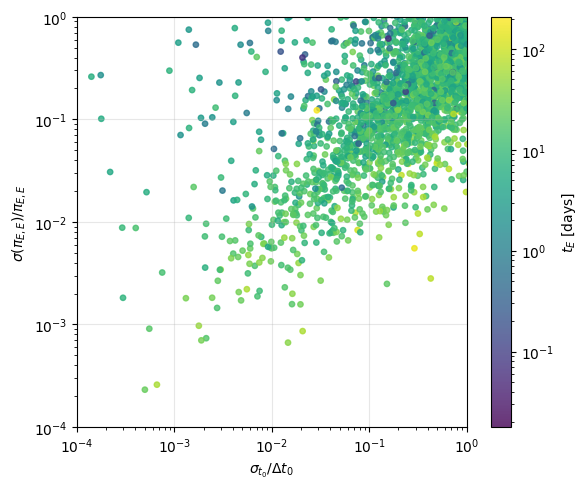

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from read_results_ import read_results

model = 'FSPL'
system_type = "FFP"

true, fit_roman, fit_rr, met_1_roman, met_1_rr, met_2_roman, met_2_rr, met_3_roman, met_3_rr, met1_ratio, met2_ratio, met3_ratio = read_results(system_type, model)

mets_list = [
    (met_1_rr, met_1_roman),
    (met_2_rr, met_2_roman),
    (met_3_rr, met_3_roman),
]

def add_delta_u0_t0(df):
    df = df.copy()
    df["delta_t0"] = df["piEE"] * df["tE"] * 0.01
    df["delta_u0"] = df["piEN"] * 0.01
    return df

fit_rr = add_delta_u0_t0(fit_rr)
true = add_delta_u0_t0(true)
fit_roman = add_delta_u0_t0(fit_roman)

cols = ['Source', 'Set']

# ------------------------------------------------------------
# Agregado nuevo:
# además de delta_t0_true, mergeo tE desde true para usarlo
# como color en el scatter
# ------------------------------------------------------------
df = fit_rr.merge(
    true[cols + ['delta_t0', 'tE']].rename(columns={
        'delta_t0': 'delta_t0_true',
        'tE': 'tE_true'
    }),
    on=cols,
    how='inner'
)

x = df['t0_err'] / df['delta_t0_true']
y = df['piEE_err'] / df['piEE']
c = df['tE_true']

mask = (
    np.isfinite(x) &
    np.isfinite(y) &
    np.isfinite(c) &
    (x > 0) &
    (y > 0) &
    (c > 0)
)

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x[mask],
    y[mask],
    c=c[mask],
    norm=LogNorm(vmin=c[mask].min(), vmax=c[mask].max()),
    cmap='viridis',
    s=15,
    alpha=0.8
)

plt.xlabel(r'$\sigma_{t_0}/\Delta t_0$')
plt.ylabel(r'$\sigma(\pi_{E,E})/\pi_{E,E}$')
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3)

# en escala log no puede haber límite inferior 0
plt.xlim(1e-4, 1)
plt.ylim(1e-4, 1)

cbar = plt.colorbar(sc)
cbar.set_label(r'$t_E$ [days]')

plt.tight_layout()
plt.show()

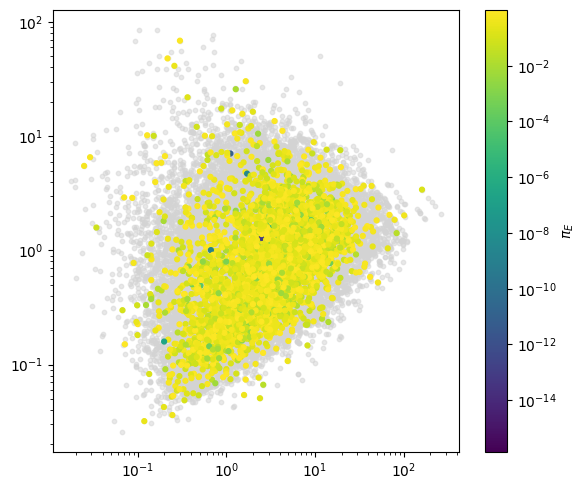

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

x = true["tE"]
y = true["piE"]
c = met_3_rr["piE"]

mask_all = (
    np.isfinite(x) &
    np.isfinite(y) &
    np.isfinite(c) &
    (x > 0) &
    (y > 0) &
    (c > 0)
)

mask_color = mask_all & (c < 1)

plt.figure(figsize=(6,5))

# --- puntos grises (todos)
plt.scatter(
    x[mask_all],
    y[mask_all],
    color="lightgray",
    s=10,
    alpha=0.5
)

# --- puntos coloreados (solo piE < 1)
sc = plt.scatter(
    x[mask_color],
    y[mask_color],
    c=c[mask_color],
    cmap="viridis",
    norm=LogNorm(vmin=c[mask_color].min(), vmax=c[mask_color].max()),
    s=12)

plt.xscale("log")
plt.yscale("log")
cbar = plt.colorbar(sc)
cbar.set_label(r'$\pi_E$')
plt.tight_layout()
plt.show()

In [6]:
events_bad_fit = []

for p in ['t0', 'u0', 'tE', 'piEE', 'piEN']:
    events_bad_fit.append(
        fit_roman[fit_roman[p + '_err'] == 0][["Source", "Set"]]
    )

# Unión de todos los dataframes, quitando duplicados
events_bad_fit = (
    pd.concat(events_bad_fit, ignore_index=True)
      .drop_duplicates()
      .reset_index(drop=True)
)

# events_bad_fit


In [7]:
# events_bad_fit contiene ["Source", "Set"] sin duplicados

events_good_fits = (
    fit_roman
    .merge(events_bad_fit, on=["Source", "Set"], how="left", indicator=True)
)

# Filtrar solo las filas que NO estén en events_bad_fit
events_good_fits = events_good_fits[events_good_fits["_merge"] == "left_only"]

# Eliminar columna auxiliar
events_good_fits = events_good_fits.drop(columns="_merge").reset_index(drop=True)
# events_good_fits

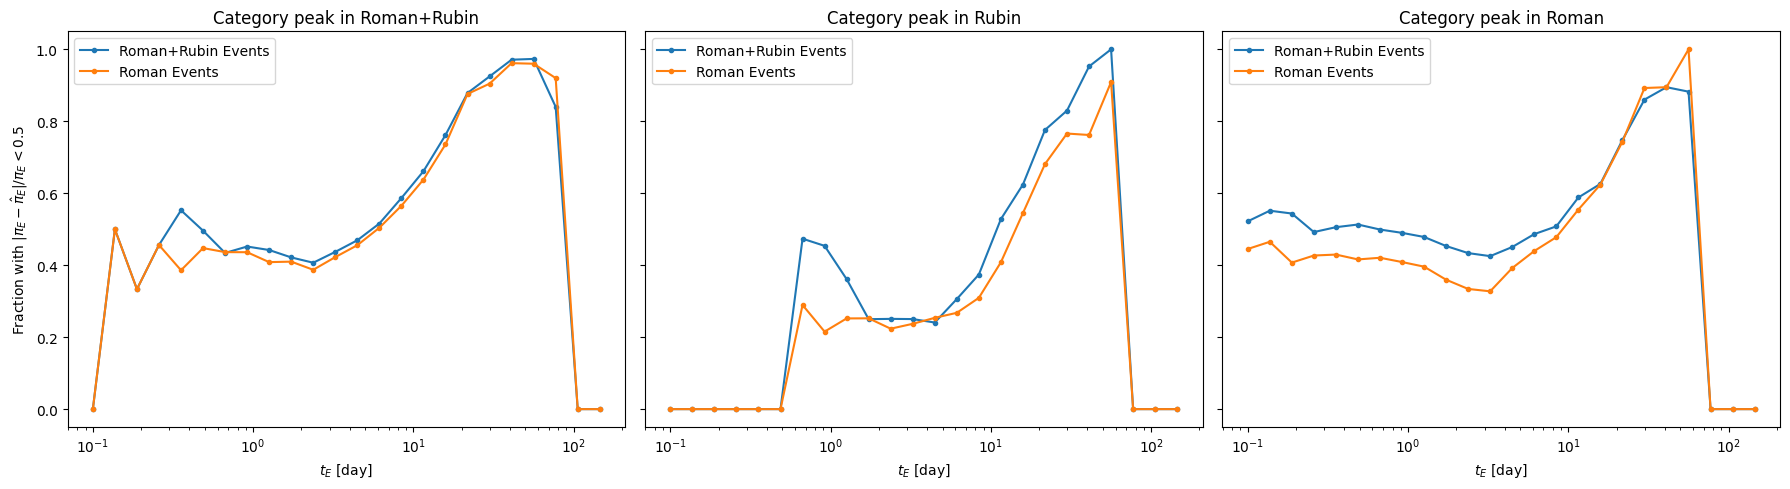

In [9]:
bins = np.logspace(-1, 2.3, 25)
x = bins[:-1]
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
# ------------------ Categoría A (pico en Roman+Rubin) ------------------
cat = 'A'
# numerador usando met_3_rr
true_filtered_rerror = true_filtered.merge(
    met_1_rr[met_1_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner')
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[0].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

# numerador usando met_3_roman
true_filtered_rerror = true_filtered.merge(
    met_1_roman[met_1_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[0].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')

axs[0].set_xscale('log')
axs[0].set_title('Category peak in Roman+Rubin')
axs[0].set_xlabel(r'$t_E$ [day]')
axs[0].set_ylabel('Fraction with $|\pi_E-\hat{\pi}_E|/\pi_E < 0.5$')
axs[0].legend()

# ------------------ Categoría B (pico en Rubin) ------------------
cat = 'B'
true_filtered_rerror = true_filtered.merge(
    met_1_rr[met_1_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[1].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

true_filtered_rerror = true_filtered.merge(
    met_1_roman[met_1_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[1].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')
axs[1].set_xscale('log')
axs[1].set_title('Category peak in Rubin')
axs[1].set_xlabel(r'$t_E$ [day]')
axs[1].legend()

# ------------------ Categoría C (pico en Roman) ------------------
cat = 'C'

true_filtered_rerror = true_filtered.merge(
    met_1_rr[met_1_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[2].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

true_filtered_rerror = true_filtered.merge(
    met_1_roman[met_1_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[2].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')

axs[2].set_xscale('log')
axs[2].set_title('Category peak in Roman')
axs[2].set_xlabel(r'$t_E$ [day]')
axs[2].legend()

plt.tight_layout()
plt.show()


In [12]:
for cat in ['A','B','C']:
    n_bot = (true_filtered['peak_flag'] == cat).sum()
    n_rr = (rr['peak_flag'] == cat).sum()
    n_rom = (rom['peak_flag'] == cat).sum()
    print(cat, "N_bot =", n_bot, "N_rr =", n_rr, "N_rom =", n_rom)

A N_bot = 18943 N_rr = 1489 N_rom = 1151
B N_bot = 6153 N_rr = 199 N_rom = 63
C N_bot = 38813 N_rr = 627 N_rom = 425


In [25]:
p = "rho" if ("rho" in true.columns) else "piE"
time = np.logspace(1,3,50)

all_ratios = []  # <- acumulador

for k, met in enumerate([[met_1_rr, met_1_roman],
                         [met_2_rr, met_2_roman],
                         [met_3_rr, met_3_roman]]):

    for cat in ["A","B","C"]:
        for t_tresh in range(len(time)-1):
            ti, tf = time[t_tresh], time[t_tresh+1]

            keys = true.loc[
                (true["peak_flag"]==cat) & (true["tE"]>ti) & (true["tE"]<tf),
                ["Source","Set"]
            ]
            m_rr    = met[0].merge(keys, on=["Source","Set"], how="inner").dropna(subset=[p]).set_index(["Source","Set"])
            m_roman = met[1].merge(keys, on=["Source","Set"], how="inner").dropna(subset=[p]).set_index(["Source","Set"])

            common = m_rr.index.intersection(m_roman.index)
            m_rr, m_roman = m_rr.loc[common].sort_index(), m_roman.loc[common].sort_index()

            # filtro en RR y re-sincronizo
            m_rr = m_rr[m_rr[p] < 0.5]
            if m_rr.empty:
                continue
            m_roman = m_roman.loc[m_rr.index]

            # construir df_ratio de ESTE bin/categoría y ACUMULAR
            df_ratio = (m_rr[p] / m_roman[p]).rename("ratio").reset_index()
            df_ratio["tE_min"] = ti
            df_ratio["tE_max"] = tf
            df_ratio["peak_flag"] = cat
            df_ratio["metric_id"] = k + 1  # opcional, por si querés saber qué métrica
            all_ratios.append(df_ratio)

# concatenar TODO al final
df_all = pd.concat(all_ratios, ignore_index=True)


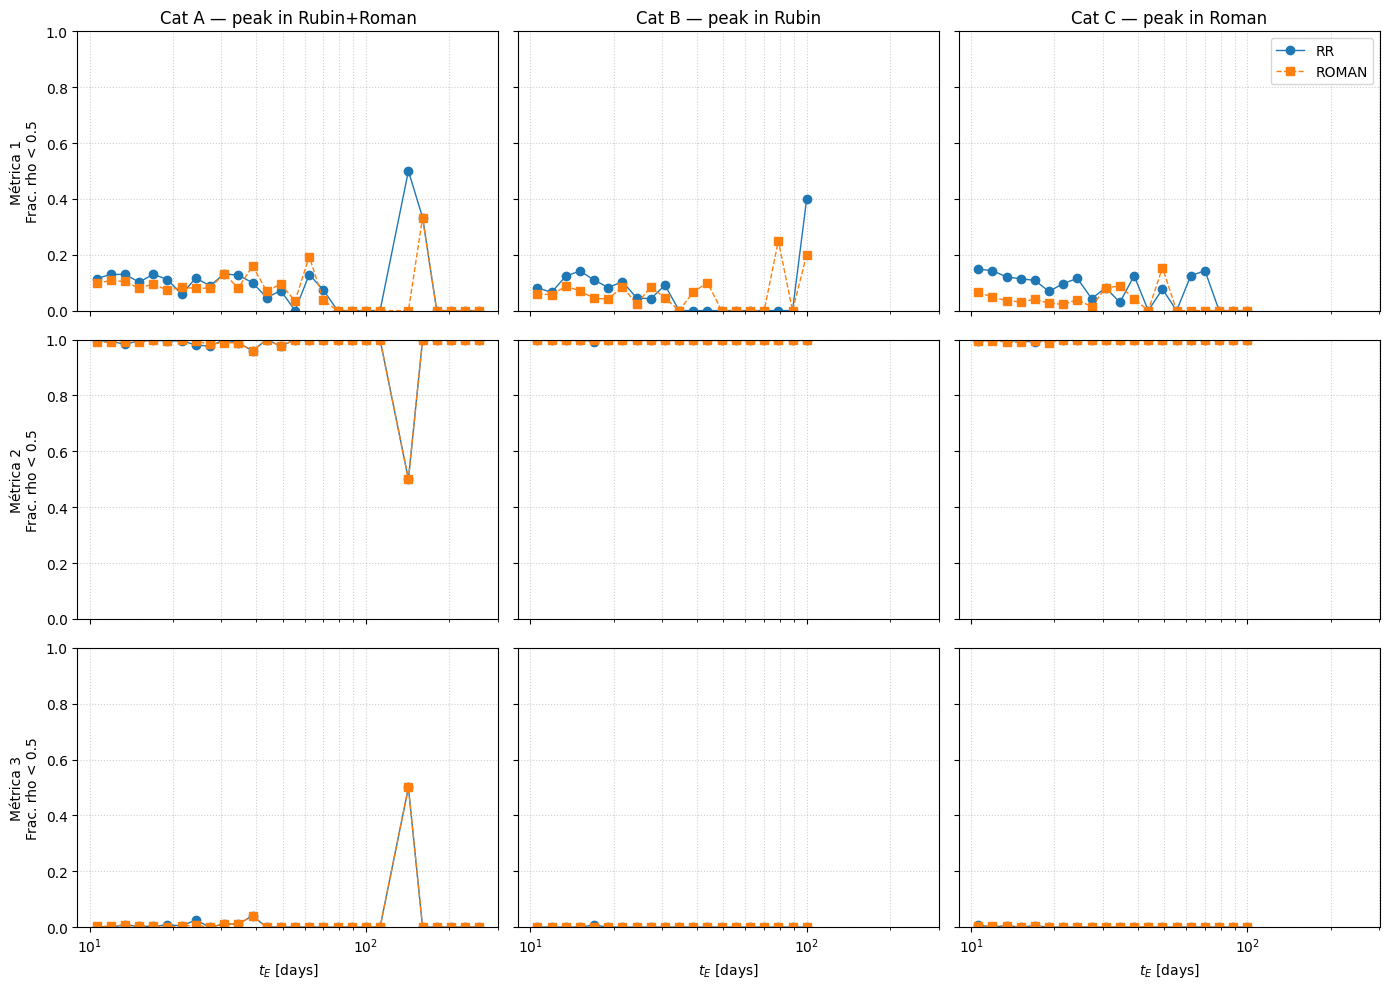

In [15]:

# =========================
# Configuración
# =========================
p = "rho" if ("rho" in true.columns) else "piE"
metric_threshold = 0.5
time_bins = np.logspace(1, 3, 40)  # bines de 10 a 1000 días
dict_cat_peak = globals().get("dict_cat_peak", {"A": "Cat A", "B": "Cat B", "C": "Cat C"})

metric_sets = [
    ("Métrica 1", (met_1_rr, met_1_roman)),
    ("Métrica 2", (met_2_rr, met_2_roman)),
    ("Métrica 3", (met_3_rr, met_3_roman)),
]
cats = ["A", "B", "C"]

# =========================
# Funciones auxiliares
# =========================
def fraction_per_bin(met_df, true_df, p, time_bins, threshold, cat):
    """Fracción por bin de tE para una categoría dada (A/B/C)."""
    x_centers, fracs = [], []
    for i in range(len(time_bins) - 1):
        ti, tf = time_bins[i], time_bins[i + 1]
        keys = true_df.loc[
            (true_df["peak_flag"] == cat) &
            (true_df["tE"] > ti) &
            (true_df["tE"] < tf),
            ["Source", "Set"]
        ]
        x_centers.append(np.sqrt(ti * tf))
        if keys.empty:
            fracs.append(np.nan)
            continue
        m = met_df.merge(keys, on=["Source", "Set"], how="inner").dropna(subset=[p])
        if len(m) == 0:
            fracs.append(np.nan)
        else:
            fracs.append((m[p] < threshold).mean())
    return np.array(x_centers), np.array(fracs)

# =========================
# Figura 3×3
# =========================
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for r, (metric_name, (df_rr, df_ro)) in enumerate(metric_sets):
    for c, cat in enumerate(cats):
        ax = axes[r, c]

        # RR
        x_rr, y_rr = fraction_per_bin(df_rr, true, p, time_bins, metric_threshold, cat)
        m_rr = np.isfinite(y_rr)
        if m_rr.any():
            ax.plot(x_rr[m_rr], y_rr[m_rr], marker='o', linestyle='-', linewidth=1.0, label="RR")

        # ROMAN
        x_ro, y_ro = fraction_per_bin(df_ro, true, p, time_bins, metric_threshold, cat)
        m_ro = np.isfinite(y_ro)
        if m_ro.any():
            ax.plot(x_ro[m_ro], y_ro[m_ro], marker='s', linestyle='--', linewidth=1.0, label="ROMAN")

        ax.set_xscale("log")
        ax.set_ylim(0, 1)
        ax.grid(True, which='both', linestyle=':', alpha=0.6)

        # Títulos y etiquetas
        if r == 0:
            ax.set_title(f"Cat {cat} — {dict_cat_peak.get(cat, cat)}")
        if c == 0:
            ax.set_ylabel(f"{metric_name}\nFrac. {p} < {metric_threshold}")
        if r == len(metric_sets) - 1:
            ax.set_xlabel(r"$t_E$ [days]")

        # Leyenda solo en la esquina superior derecha para no recargar
        if r == 0 and c == 2:
            ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()


In [28]:
binsx = np.logspace(-3, 3, 30)
binsy = np.logspace(-0.5, 0.5, 30)

# Example usage
# fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'A'
p = 'piE'
x3 = met1_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
y3 = met3_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]

lab_piE = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$",r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
lab_rho = [r"$\frac{|\rho - \hat{\rho}|_{Roman+Rubin}}{|\rho - \hat{\rho}|_{Roman}}$",r"$\frac{\sigma_{\rho}/\hat{\rho}(Roman+Rubin)}{\sigma_{\rho}/\hat{\rho}(Roman)}$"]
# create_hist2d_with_marginals(axes, x3, y3, lab_piE, p,binsx,binsy)

# plt.show()

NameError: name 'met_1_rr_filtered' is not defined

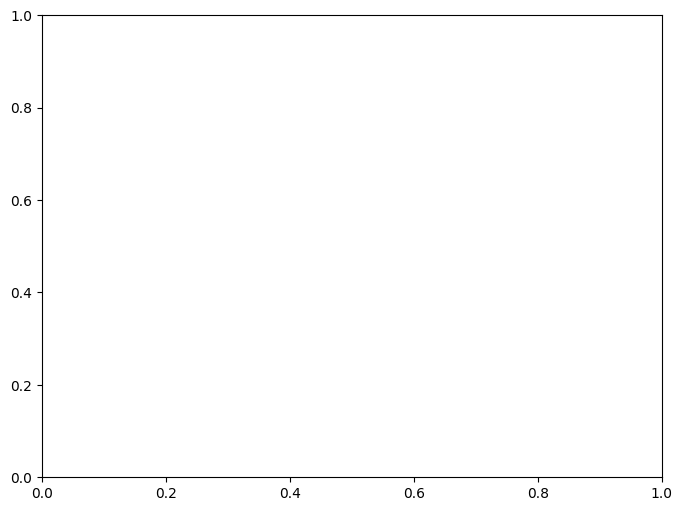

In [29]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
cat, p = 'C', 'piE'
binsx = np.logspace(-6, 0.1, 30)
binsy = np.logspace(-5, 7, 30)
# p ='piE'

y = met1_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x1 = met_1_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x2 = met_1_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]

create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\pi_E}$",r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$"], 'piE',binsx,binsy)

plt.show()

In [ ]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'B'
binsx = np.logspace(-15, 5, 30)
binsy = np.logspace(-15, 5, 30)
y = met2_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_2_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_2_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))

create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\sigma(\pi_E)}$",r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$"], 'piE',binsx,binsy)

plt.show()

In [ ]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'C'
binsx = np.logspace(-3, 3, 30)
binsy = np.logspace(-6, 1, 30)
y = met3_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_3_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_3_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))
create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{\sigma(\hat{\pi}_E)}{\hat{\pi}_E}$",r"$\frac{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman+Rubin)}{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman)}$"], 'piE',binsx,binsy)

plt.show()

# Compute mass 

In [32]:
keys = ["Source", "Set"]
p= "piE"
s_rr    = met_2_rr.set_index(keys)[p]
s_roman = met_2_roman.set_index(keys)[p]
# Limitar al cruce de claves presentes en ambos DF
common = s_rr.index.intersection(s_roman.index)
mass_mask = (s_rr.loc[common] / s_roman.loc[common]) < 1
# mass_mask es un Series booleano indexado por (Source, Set)
# Si querés el mask en el orden de met_1_rr (incluyendo claves sin par en Roman):
mass_mask_rr_order = mass_mask.reindex(met_1_rr.set_index(keys).index)
keys = ["Source", "Set"]
# Asegurar que mass_mask tenga MultiIndex y esté bien alineada
mask = mass_mask.reindex(true.set_index(keys).index).fillna(False)
# Seleccionar las filas correspondientes
df_selected = true.loc[mask.values]
# df_selected
keys = ["Source", "Set"]
# Índices donde la condición es Fals
false_keys = mass_mask[~mass_mask].index
# Seleccionar en otro DataFrame (por coincidencia de claves)
df_not_selected = true.loc[
    true.set_index(keys).index.isin(false_keys)
]

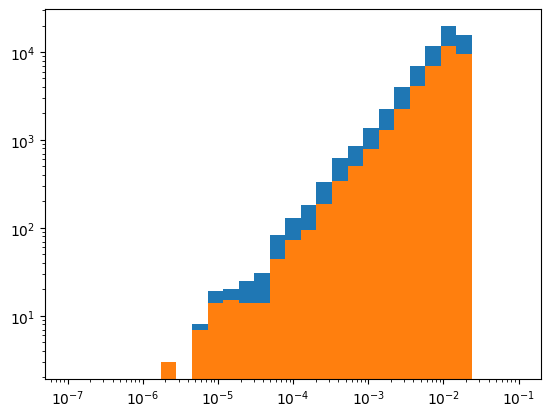

In [33]:
# plt.hist(plt.scatter(df_selected['mass'],df_selected['piE'],alpha=0.5)
plt.hist(true['mass'], bins=np.logspace(-7,-1,30))
plt.hist(df_not_selected['mass'], bins=np.logspace(-7,-1,30))#,df_not_selected['piE'],alpha=0.5))
plt.xscale("log")
plt.yscale("log")

In [ ]:
# Definir los mismos bins logarítmicos
bins = np.logspace(0, 2.1, 30)
# Calcular histogramas (sin dibujar todavía)
counts_true, edges = np.histogram(true["mass"], bins=bins)
counts_not, _     = np.histogram(df_not_selected["mass"], bins=bins)
# Evitar división por cero
ratio = np.divide(counts_not, counts_true, out=np.zeros_like(counts_true, dtype=float), where=counts_true>0)
# Calcular centro de cada bin
centers = (edges[:-1] + edges[1:]) / 2
# Graficar
plt.figure(figsize=(6,4))
plt.plot(centers, ratio, marker='o')
plt.xscale("log")
plt.yscale("linear")  # el cociente no suele necesitar escala log
plt.xlabel("Mass")
plt.ylabel(r"ratio  $RE(\pi_E)$")
plt.grid(True, which="both", ls=":")
plt.show()

In [ ]:
plt.scatter(df_selected['mass'],df_selected['piE'],alpha=0.5)
plt.scatter(df_not_selected['mass'],df_not_selected['piE'],alpha=0.5)
plt.xlabel(r'$M_L [M_{\odot}$]', fontsize=16)
plt.ylabel(r'$\pi_E $', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
plt.hist(met_1_rr['mass_v1'],np.logspace(-15,37,40),rwidth=0.9)
plt.hist(met_1_rr['mass_v2'],np.logspace(-15,37,40),histtype='step',linewidth=3)
if not model == "PSPL":
    plt.hist(met_1_rr['mass_v3'],np.logspace(-15,37,40),histtype='step',linewidth=3)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("RB(M)")
plt.show()

In [ ]:
tr